In [2]:
import pandas as pd

data = pd.read_csv('/content/WA_Fn-UseC_-Telco-Customer-Churn.csv')

data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
data.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [4]:
data['TotalCharges'] = pd.to_numeric(data['TotalCharges'], errors='coerce')

In [5]:
data.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [6]:
data = data.dropna()

In [7]:
data['Churn'] = data['Churn'].map({'Yes':1, 'No':0})

In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   object 
 1   gender            7032 non-null   object 
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   object 
 4   Dependents        7032 non-null   object 
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   object 
 7   MultipleLines     7032 non-null   object 
 8   InternetService   7032 non-null   object 
 9   OnlineSecurity    7032 non-null   object 
 10  OnlineBackup      7032 non-null   object 
 11  DeviceProtection  7032 non-null   object 
 12  TechSupport       7032 non-null   object 
 13  StreamingTV       7032 non-null   object 
 14  StreamingMovies   7032 non-null   object 
 15  Contract          7032 non-null   object 
 16  PaperlessBilling  7032 non-null   object 
 17  

In [9]:
data['Churn'].value_counts()
data['Churn'].value_counts(normalize=True) * 100

,proportion
Churn,
0,73.421502
1,26.578498


In [10]:
pd.crosstab(data['Contract'], data['Churn'])

Churn,0,1
Contract,,
Month-to-month,2220,1655
One year,1306,166
Two year,1637,48


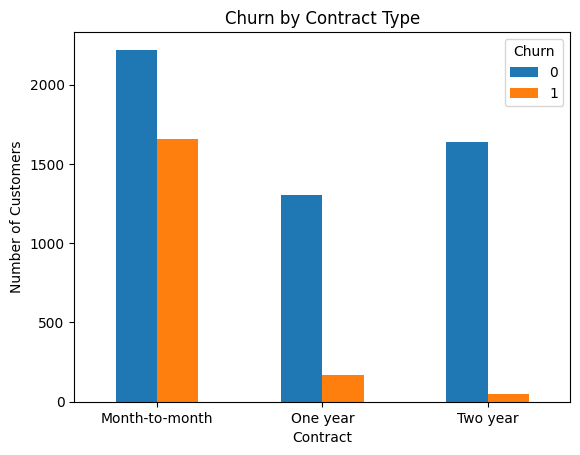

In [24]:
pd.crosstab(data['Contract'], data['Churn']).plot(kind='bar')
import matplotlib.pyplot as plt
plt.xticks(rotation=0)
plt.title('Churn by Contract Type')
plt.ylabel('Number of Customers')
plt.show()

In [25]:
data.groupby('Churn')['tenure'].mean()


,tenure
Churn,
0,37.650010
1,17.979133


In [26]:
data.groupby('Churn')['MonthlyCharges'].mean()

,MonthlyCharges
Churn,
0,61.307408
1,74.441332


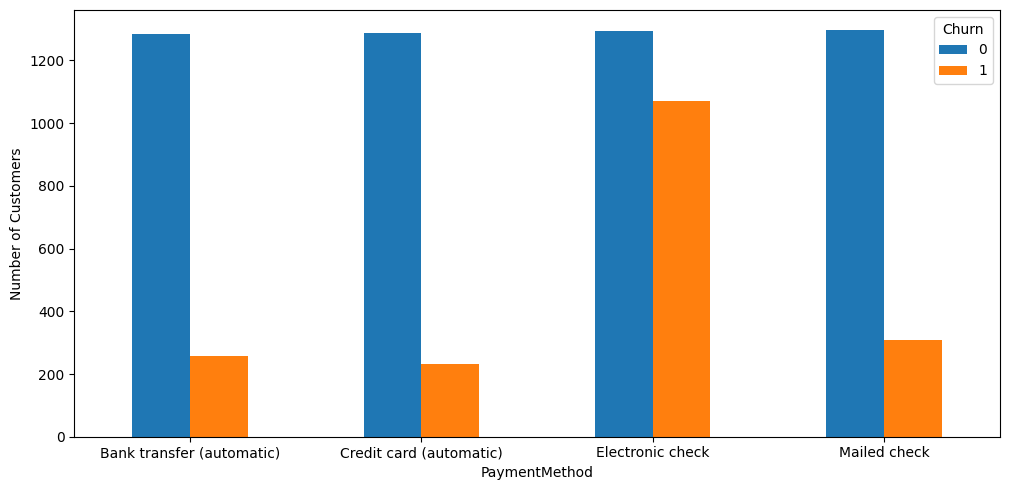

In [39]:
pd.crosstab(data['PaymentMethod'], data['Churn']).plot(kind='bar', figsize=(10,5))
plt.xticks(rotation=0)
plt.tight_layout()
plt.ylabel('Number of Customers')
plt.show()


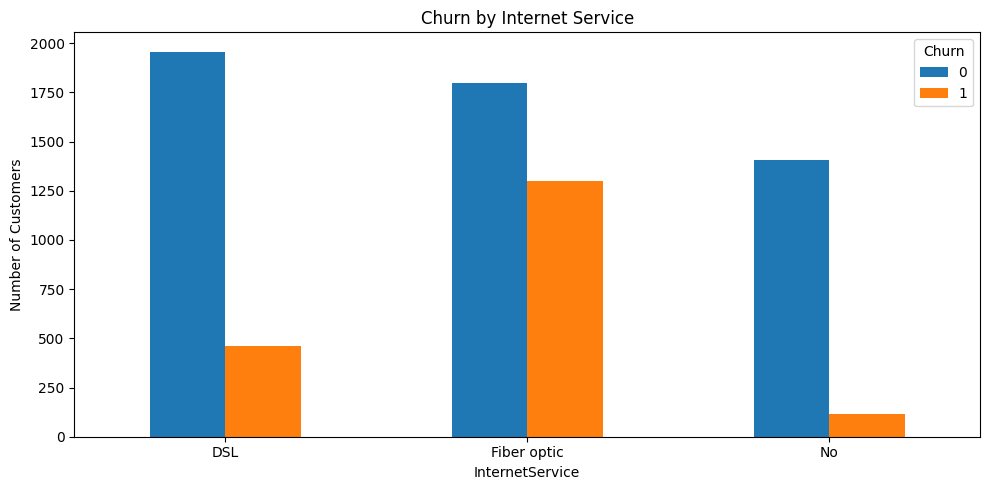

In [43]:
pd.crosstab(data['InternetService'], data['Churn']).plot(kind='bar', figsize=(10,5))

import matplotlib.pyplot as plt
plt.xticks(rotation=0)
plt.ylabel('Number of Customers')
plt.title('Churn by Internet Service')
plt.tight_layout()
plt.show()

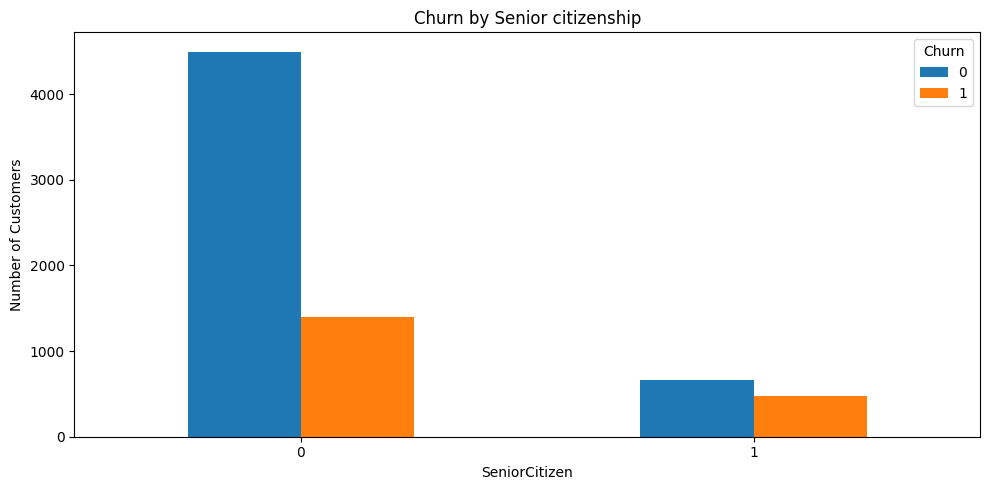

In [46]:
pd.crosstab(data['SeniorCitizen'], data['Churn']).plot(kind='bar',figsize=(10,5))

import matplotlib.pyplot as plt
plt.xticks(rotation=0)
plt.ylabel('Number of Customers')
plt.title('Churn by Senior citizenship')
plt.tight_layout()
plt.show()